# 📚 Final Project — Introduction to Deep Learning
## Image Classification with Convolutional Neural Networks (CNNs)

---

### 🔍 Overview
Design, train, and analyze **convolutional neural networks (CNNs)** for an image classification problem of your choice (the same one selected in Exercise 1). You previously built a dataset (~1,000 images) and trained a classifier using **fastai**. In this project, you will implement and train your own network in **PyTorch** (without fastai).

> **Focus is not only on accuracy.** Emphasize architectural choices, optimization strategies, hyperparameter tuning, overfitting vs generalization, and explaining *why* things worked or didn’t.

---

### 🎯 Learning Goals
- Design and train CNN architectures for image classification  
- Experiment with optimization algorithms and hyperparameters  
- Apply batch normalization and regularization techniques  
- Use transfer learning effectively  
- Work with pretrained networks (e.g., ResNet50)  
- Analyze and communicate experimental results clearly  

---

### 🧭 Project Structure (Summary)
- **Part 1 — Training a CNN from Scratch**  
  Build models, compare architectures/optimizers/hyperparameters; add batch norm & regularization; analyze overfitting vs generalization.
- **Part 2 — Transfer Learning**  
  Pretrain on an external dataset (e.g., CIFAR-10), then fine-tune on your dataset; compare with training from scratch.
- **Part 3 — Transfer learning with a Pretrained Network (ResNet50)**  
  Adapt ResNet50, replace the final layer, experiment with freezing/unfreezing and fine-tuning.

---

### 📦 Deliverables
- **Code:** All notebooks & scripts, clear structure/documentation, hosted in your **GitHub repo** from Exercise 1.  
- **Presentation (PPT):** Problem & dataset, experiments & results, comparisons & conclusions, final reflection.

---

### 🧪 Evaluation Criteria
- Experimental rigor  
- Quality of analysis  
- Clarity of explanations  
- Thoughtfulness of conclusions  
- Code organization & reproducibility  

*Accuracy alone is **not** the main criterion.*

---

### 📜 Academic Integrity
You may use external resources for reference, but:
- All work must be your own  
- You must understand and explain every line of code you submit  

---

## 📎 Appendix — Detailed Instructions (Click to expand)

<details>
  <summary><strong>Part 1 — Training a CNN from Scratch</strong></summary>

  ### Step 1 — Architecture & Optimization
  1. Choose <strong>at least two different CNN architectures</strong> (e.g., shallow vs deeper CNN).
  2. Compare <strong>optimization algorithms</strong> such as Adam and SGD with momentum.
  3. Tune key hyperparameters: <em>learning rate, batch size, number of epochs</em>.

  **Document every experiment clearly.** Explain:  
  - Why you chose each architecture  
  - How hyperparameters affected training  
  - What worked vs what didn’t  

  ### Step 2 — Add Batch Normalization
  Modify your best-performing architecture by adding <strong>Batch Normalization</strong> layers. Analyze:  
  - Training stability  
  - Convergence speed  
  - Validation performance  

  *Compare results with and without batch normalization.*

  ### Step 3 — Add Regularization
  Add <strong>regularization techniques</strong>:
  - Dropout  
  - Weight decay (L2 regularization)  
  - Data augmentation  

  Analyze:
  - Overfitting vs generalization  
  - Training vs validation curves  

  *Explain which regularization methods helped and why.*

  > Note: Depending on your dataset size and problem complexity, accuracy in Part 1 may be limited—you may need more data.
</details>

<details>
  <summary><strong>Part 2 — Transfer Learning</strong></summary>

  ### Step 4 — Pretraining on an External Dataset
  1. Choose an external image dataset (e.g., CIFAR-10 or another public dataset).  
  2. Train your CNN architecture on this dataset (or a subset if it’s too large).  
  3. Adjust your architecture as needed.  
  4. Save the trained weights.  

  *Explain why this dataset is relevant and what features it may teach the model.*

  ### Step 5 — Fine-Tuning on Your Dataset
  1. Load the pretrained weights.  
  2. Fine-tune the network using your dataset.  
  3. Compare results with training from scratch.  

  Analyze:
  - Speed of convergence  
  - Final accuracy  
  - Generalization  

  **Notes:**
  1. You may need to adjust image sizes/shapes to match your network’s expected input.  
  2. Adjust the final classification layer to the number of classes in the target dataset.
</details>

<details>
  <summary><strong>Part 3 — Transfer learning with a Pretrained Network (ResNet50)</strong></summary>

  ### Step 6 — Adapting a Pretrained Model
  1. Load <strong>ResNet50 pretrained on ImageNet</strong>.  
  2. Replace the final classification layer to match your number of classes.  
  3. Freeze and unfreeze layers as needed.  

  *Explain your design choices.*

  ### Step 7 — Training & Fine-Tuning
  1. Fine-tune the modified ResNet50 on your dataset.  
  2. Experiment with: freezing vs unfreezing layers, learning rates, and data augmentation.  

  Compare:
  - Performance vs your custom CNN  
  - Training time  
  - Stability  
</details>

<details>
  <summary><strong>Results & Analysis</strong></summary>

  Include:
  - Training & validation curves  
  - Quantitative metrics (accuracy, loss)  
  - Qualitative observations  
  - Short conclusions  

  **Focus on reasoning, not just numbers.**
</details>

<details>
  <summary><strong>Final Reflection</strong></summary>

  Reflect on:
  - What architectural choices mattered most?  
  - Which optimization strategies worked best?  
  - When did transfer learning help?  
  - What would you do differently with more time or data?  
</details>

<details>
  <summary><strong>What to Submit</strong></summary>

  - <strong>Code:</strong> All notebooks & scripts, clear structure & documentation, hosted in your <strong>GitHub repo</strong> from Exercise 1.  
  - <strong>Presentation (PPT):</strong> Problem & dataset, each experiment, results & comparisons, considerations & conclusions, final reflection.  

  *Explain your reasoning after every experiment.*
</details>

In [2]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import confusion_matrix
from torchvision import datasets
import seaborn as sns
from torch.utils.data import Subset
import matplotlib.pyplot as plt
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from fastai.vision.all import *
import random
import copy

In [3]:
CLASSES = ['beagle', 'boxer']
test_size = 0.2
CIFAR_subset = 0.1

path = untar_data(URLs.PETS)
fnames = get_image_files(path/"images")
print(f"Total files found: {len(fnames)}")

selected_files = [f for f in fnames if any(breed in f.name.lower() for breed in CLASSES)]

random.shuffle(selected_files)
split_idx = int(len(selected_files) * (1 - test_size))
train_files = selected_files[:split_idx]
test_files = selected_files[split_idx:]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # data augmentation methods #
      transforms.RandomHorizontalFlip(p=0.5),
      transforms.RandomRotation(degrees=15),
    # data augmentation methods #
    transforms.ToTensor(),
    # data normalization
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_data = []
for img_path in train_files:
    img = Image.open(img_path).convert('RGB')
    img_tensor = train_transform(img)
    label = 0 if 'beagle' in img_path.name.lower() else 1
    train_data.append((img_tensor, torch.tensor(label, dtype=torch.long)))

test_data = []
for img_path in test_files:
    img = Image.open(img_path).convert('RGB')
    img_tensor = test_transform(img)
    label = 0 if 'beagle' in img_path.name.lower() else 1
    test_data.append((img_tensor, torch.tensor(label, dtype=torch.long)))

cifar_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.491, 0.482, 0.446], std=[0.247, 0.243, 0.261])
])

# creating DataLoader objects for our model
cifar_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)
num_samples = int(len(cifar_train) * CIFAR_subset)
indices = torch.randperm(len(cifar_train))[:num_samples]
cifar_subset = Subset(cifar_train, indices)
cifar_loader = DataLoader(cifar_subset, batch_size=64, shuffle=True)
print(f'CIFAR size : {len(cifar_loader.dataset)}')

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


print(f"Train size: {len(train_loader.dataset)}")
print(f"Test size: {len(test_loader.dataset)}")


<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:48&lt;00:00]</div>

Total files found: 7390


100%|██████████| 170M/170M [00:11<00:00, 15.0MB/s]


CIFAR size : 5000
Train size: 320
Test size: 80


In [4]:
def plot_losses(losses):
    plt.figure(figsize=(10, 6))
    plt.plot(losses, label='Loss')
    plt.title("loss over iterations")
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

In [4]:
criterion = nn.BCELoss()

class myNet(nn.Module):
    def __init__(self):
        # Batch normalization layers + dropout implemented in the network.
        super(myNet, self).__init__()
        torch.manual_seed(0)
        self.cnn1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.cnn2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.cnn3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(p=0.5)
        self.fc1 = nn.Linear(64 * 28 * 28, 1)
        #self.fc1 = nn.Linear(64 * 28 * 28, 10) # for the CIFAR dataset


    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.cnn1(x))))
        x = self.pool2(torch.relu(self.bn2(self.cnn2(x))))
        x = self.pool3(torch.relu(self.bn3(self.cnn3(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc1(x)
        x = torch.sigmoid(x)
        return x


    def run_train(self, epochs, loader):
        #optimizer = optim.SGD(self.parameters(),momentum=0.9, lr=0.0001)
        # regularization method : weights decay. initial value : 0.0001
        optimizer = optim.SGD(self.parameters(),momentum=0.9, lr=0.0001, weight_decay=1e-4)

        LOSS = []
        min_loss = float('inf')
        min_weights = []
        min_iteration = 0
        # pocket algorithm : keep the weights with the lowest loss achieved during the epochs
        for epoch in range(epochs):
            for data, target in loader:
                optimizer.zero_grad()
                output = self(data)

                target = target.unsqueeze(1).float()
                loss = criterion(output, target)

                loss.backward()
                optimizer.step()
                LOSS.append(loss.item())
                if loss.item() < min_loss:
                  min_loss = loss.item()
                  best_model_wts = copy.deepcopy(self.state_dict())
                  min_iteration = epoch
            print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')
        print(f'Min loss : {min_loss:.4f} in iteration {min_iteration}')

        self.load_state_dict(best_model_wts)
        plot_losses(LOSS)
        return LOSS


    def run_test(self, loader):
        all_preds = []
        all_labels = []
        self.eval()

        with torch.no_grad():
            for x, y in loader:
                scores = self(x)
                preds = (scores > 0.5).float()
                # Used when converted the network to fit the CIFAR dataset
                #_, preds = torch.max(scores, 1)

                all_preds.extend(preds.numpy())
                all_labels.extend(y.numpy())

        self.train()
        return all_labels, all_preds

Epoch 1, Loss: 0.7506
Epoch 2, Loss: 0.6911
Epoch 3, Loss: 0.6026
Epoch 4, Loss: 0.5712
Epoch 5, Loss: 0.4581
Epoch 6, Loss: 0.5295
Epoch 7, Loss: 0.4607
Epoch 8, Loss: 0.3753
Epoch 9, Loss: 0.2740
Epoch 10, Loss: 0.3139
Epoch 11, Loss: 0.2545
Epoch 12, Loss: 0.2884
Min loss : 0.2251 in iteration 11


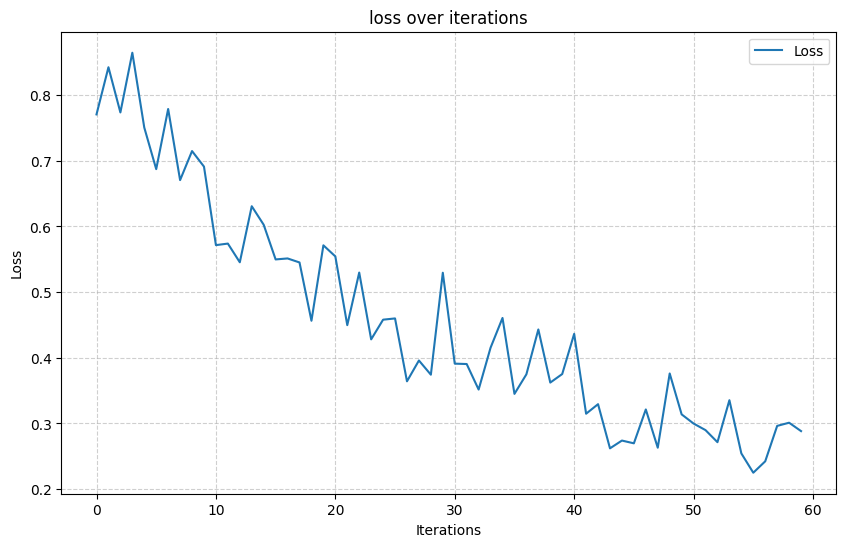

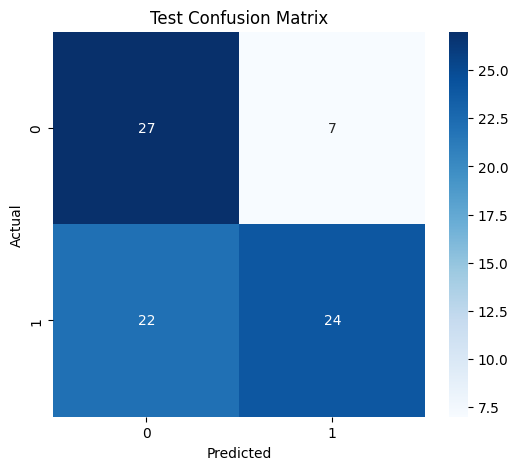

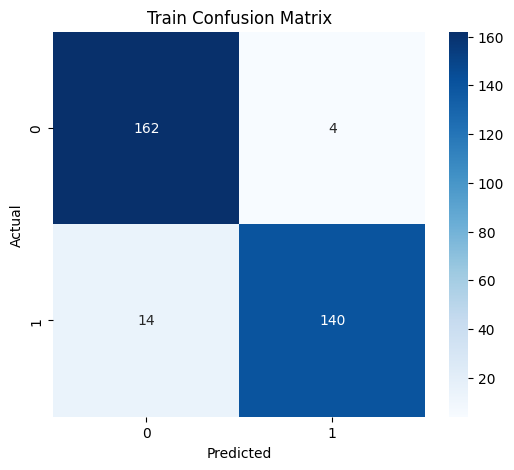

In [7]:
net = myNet()
net.run_train(12, train_loader)
labels, preds = net.run_test(test_loader)

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test Confusion Matrix')
plt.show()

labels, preds = net.run_test(train_loader)

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Train Confusion Matrix')
plt.show()

In [14]:
# methods to run before training the resnet50 model on the new data

criterion = nn.BCEWithLogitsLoss()
def run_train_resnet(epochs, loader, resnet):
    trainable_params = [p for p in resnet.parameters() if p.requires_grad]
    optimizer = optim.SGD(trainable_params, momentum=0.9, lr=0.001, weight_decay=1e-4)

    LOSS = []
    min_loss = float('inf')
    best_model_wts = copy.deepcopy(resnet.state_dict())
    min_iteration = 0

    resnet.train()

    for epoch in range(epochs):
        running_loss = 0.0
        for data, target in loader:
            optimizer.zero_grad()
            output = resnet(data)

            target = target.unsqueeze(1).float()
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            LOSS.append(loss.item())
            if loss.item() < min_loss:
                min_loss = loss.item()
                best_model_wts = copy.deepcopy(resnet.state_dict())
                min_iteration = epoch

        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

    print(f'Min loss : {min_loss:.4f} in iteration {min_iteration+1}')
    resnet.load_state_dict(best_model_wts)
    plot_losses(LOSS)
    return LOSS


def run_test_resnet(loader, model):
    all_preds = []
    all_labels = []
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            scores = model(x)
            probs = torch.sigmoid(scores)
            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    model.train()
    return all_labels, all_preds


Epoch 1, Loss: 0.6845
Epoch 2, Loss: 0.6503
Epoch 3, Loss: 0.6094
Epoch 4, Loss: 0.5569
Epoch 5, Loss: 0.5070
Epoch 6, Loss: 0.4707
Epoch 7, Loss: 0.4333
Epoch 8, Loss: 0.4030
Epoch 9, Loss: 0.3674
Epoch 10, Loss: 0.3497
Epoch 11, Loss: 0.3128
Epoch 12, Loss: 0.3190
Min loss : 0.2916 in iteration 12


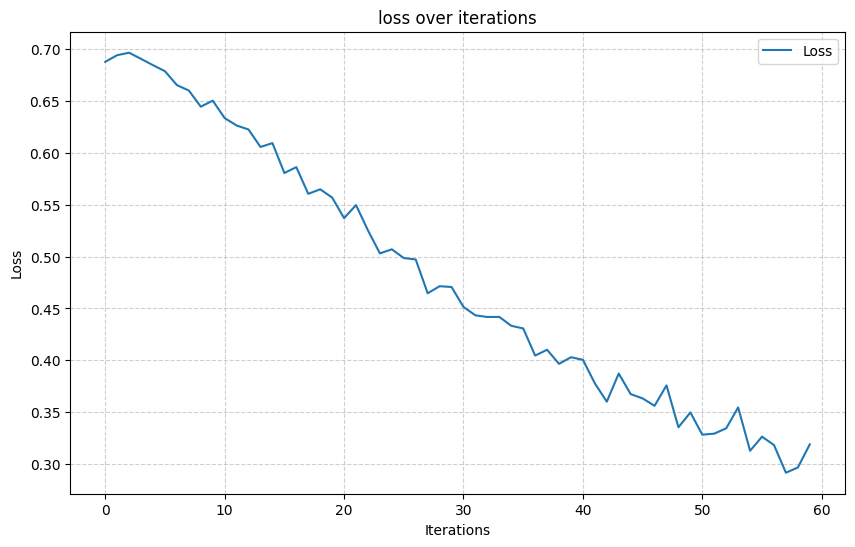

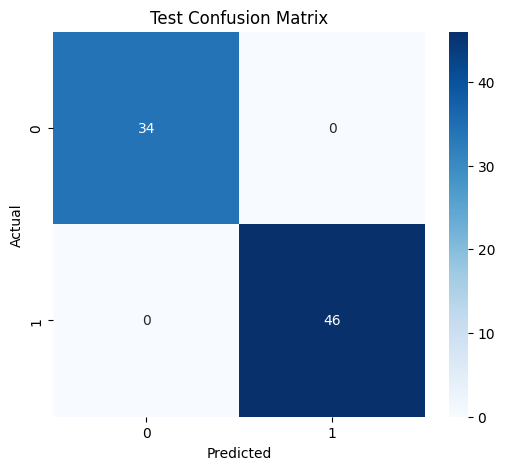

In [15]:
from torchvision import models

resnet50 = models.resnet50(weights='DEFAULT')

for param in resnet50.parameters():
    param.requires_grad = False

num_ftrs = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_ftrs, 1)
run_train_resnet(12, train_loader, resnet50)
labels, preds = run_test_resnet(test_loader,resnet50)

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test Confusion Matrix')
plt.show()


In [20]:
criterion = nn.BCELoss()

class myNet(nn.Module):
    def __init__(self):
        # Batch normalization layers + dropout implemented in the network.
        super(myNet, self).__init__()
        torch.manual_seed(0)
        self.cnn1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.cnn2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.cnn3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(p=0.5)
        #self.fc1 = nn.Linear(64 * 28 * 28, 1)
        self.fc1 = nn.Linear(64 * 28 * 28, 10) # for the CIFAR dataset


    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.cnn1(x))))
        x = self.pool2(torch.relu(self.bn2(self.cnn2(x))))
        x = self.pool3(torch.relu(self.bn3(self.cnn3(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc1(x)
        #x = torch.sigmoid(x)
        return x


    def run_train(self, epochs, loader):
        #optimizer = optim.SGD(self.parameters(),momentum=0.9, lr=0.0001)
        # regularization method : weights decay. initial value : 0.0001
        optimizer = optim.SGD(self.parameters(),momentum=0.9, lr=0.0001, weight_decay=1e-2)

        LOSS = []
        min_loss = float('inf')
        min_weights = []
        min_iteration = 0
        # pocket algorithm : keep the weights with the lowest loss achieved during the epochs
        for epoch in range(epochs):
            for data, target in loader:
                optimizer.zero_grad()
                output = self(data)

                output = torch.sigmoid(output)
                target = target.unsqueeze(1).float()
                loss = criterion(output, target)

                loss.backward()
                optimizer.step()
                LOSS.append(loss.item())
                if loss.item() < min_loss:
                  min_loss = loss.item()
                  best_model_wts = copy.deepcopy(self.state_dict())
                  min_iteration = epoch
            print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')
        print(f'Min loss : {min_loss:.4f} in iteration {min_iteration}')

        self.load_state_dict(best_model_wts)
        plot_losses(LOSS)
        return LOSS


    def run_test(self, loader):
        all_preds = []
        all_labels = []
        self.eval()

        with torch.no_grad():
            for x, y in loader:
                scores = self(x)
                probs = torch.sigmoid(scores)
                preds = (probs > 0.5).float()

                all_preds.extend(preds.numpy())
                all_labels.extend(y.numpy())

        self.train()
        return all_labels, all_preds

In [21]:
# loading the weights to the -modified- network

net = myNet()

pretrained_weights = torch.load('cifar_pretrained_weights.pth')
net.load_state_dict(pretrained_weights)

print("Pretrained weights loaded successfully.")

num_ftrs = net.fc1.in_features
net.fc1 = nn.Linear(num_ftrs, 1)

criterion = nn.BCELoss()

Pretrained weights loaded successfully.


In [ ]:
net.run_train(10, train_loader)
labels, preds = net.run_test(test_loader)

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test Confusion Matrix')
plt.show()

labels, preds = net.run_test(train_loader)

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Train Confusion Matrix')
plt.show()

Epoch 1, Loss: 2.1369
Epoch 2, Loss: 1.3149
Epoch 3, Loss: 1.2247
Epoch 4, Loss: 2.0070
Epoch 5, Loss: 0.9654
Epoch 6, Loss: 0.5760
Epoch 7, Loss: 0.6886
Epoch 8, Loss: 0.9480
Epoch 9, Loss: 1.0437
Epoch 10, Loss: 1.4922
Epoch 11, Loss: 0.9073
Epoch 12, Loss: 0.5317
Min loss : 0.5213 in iteration 11


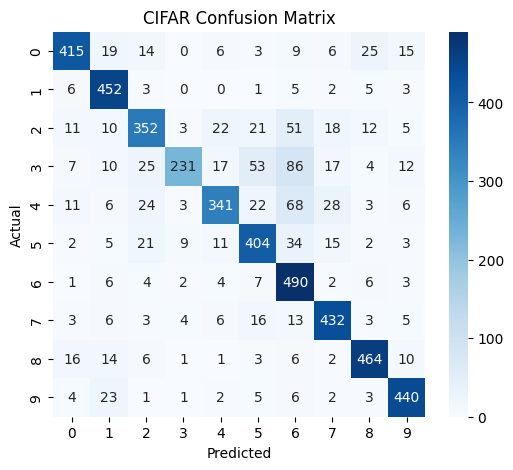

In [139]:
# Do not run ! the network was modified to fit the dataset but was modified back.
# was used to get and save the weights and it takes 1h+.

net = myNet()
net.run_train(12,cifar_loader)
labels, preds = net.run_test(cifar_loader)

cm = confusion_matrix(labels, preds)
torch.save(net.state_dict(), 'cifar_pretrained_weights.pth')
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CIFAR Confusion Matrix')
plt.show()